In [6]:
EPS = 4/255; PGD_BATCH = 64; SEED = 42
LR = 5e-5; EPOCHS = 10; N_TEST = 759; N_CLASSES = 13

In [7]:
!pip install ultralytics -q

import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, os, shutil, random, copy, csv, time
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name()}')

Device: cuda
GPU: NVIDIA L4


In [8]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile

BASE_SAVE_DIR = '/content/drive/MyDrive/recaptcha dataset with rare samples'
DATASET_ROOT = '/content/recaptcha-dataset-master'
TRAIN_DIR = os.path.join(DATASET_ROOT, 'Training')
VAL_DIR   = os.path.join(DATASET_ROOT, 'Validation')
CHECKPOINT_DIR = os.path.join(BASE_SAVE_DIR, 'self_healing_pgd_oversampled_v2')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

if not os.path.isdir(DATASET_ROOT):
    with zipfile.ZipFile(os.path.join(BASE_SAVE_DIR, 'recaptcha-dataset-master.zip'), 'r') as z:
        z.extractall('/content')
    print('Extracted.')
else:
    print('Dataset ready.')

from ultralytics import YOLO
MODEL_DST = '/content/classification_model.pt'
if not os.path.exists(MODEL_DST):
    shutil.copy(os.path.join(BASE_SAVE_DIR, 'classification_model.pt'), MODEL_DST)

yolo = YOLO(MODEL_DST)
torch_model = yolo.model.to(device).eval()

def forward_probs(model, x):
    out = model(x.to(device))
    return out[0] if isinstance(out, tuple) else out

IMG_SIZE = 128
CLASS_NAMES = yolo.names
NAME_TO_IDX = {v: k for k, v in CLASS_NAMES.items()}
preprocess = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()])
import PIL.Image
_original_open = PIL.Image.open.__wrapped__ if hasattr(PIL.Image.open, '__wrapped__') else PIL.Image.open

print(f'Model loaded. Checkpoint dir: {CHECKPOINT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset ready.
Model loaded. Checkpoint dir: /content/drive/MyDrive/recaptcha dataset with rare samples/self_healing_pgd_oversampled_v2


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# Load PGD adversarial images + VLM labels from Steps 1+2 v2
# ══════════════════════════════════════════════════════════════════════════════
SAVE_ROOT_DRIVE = os.path.join(BASE_SAVE_DIR, 'all_samples_untargeted_pgd_eps4_v2')
DRIVE_ZIP = os.path.join(SAVE_ROOT_DRIVE, 'adversarial_images.zip')
LOCAL_ROOT = '/content/pgd_eps4_v2_local'

assert os.path.exists(os.path.join(SAVE_ROOT_DRIVE, 'results.csv')), 'Step 1 v2 not complete'
assert os.path.exists(os.path.join(SAVE_ROOT_DRIVE, 'vlm_results.csv')), 'Step 2 v2 not complete'

if not os.path.isdir(LOCAL_ROOT):
    t0 = time.time()
    print('Copying + unzipping adversarial images...')
    shutil.copy(DRIVE_ZIP, '/content/adversarial_images_v2.zip')
    os.makedirs(LOCAL_ROOT, exist_ok=True)
    with zipfile.ZipFile('/content/adversarial_images_v2.zip', 'r') as z: z.extractall(LOCAL_ROOT)
    os.remove('/content/adversarial_images_v2.zip')
    print(f'  Done in {time.time()-t0:.0f}s')
else:
    print('Local copy exists.')

ADV_LOCAL = os.path.join(LOCAL_ROOT, 'adversarial_images')

saved_results = []
with open(os.path.join(SAVE_ROOT_DRIVE, 'results.csv'), 'r') as f:
    for row in csv.DictReader(f): saved_results.append(row)

vlm_preds = {}
with open(os.path.join(SAVE_ROOT_DRIVE, 'vlm_results.csv'), 'r') as f:
    for row in csv.DictReader(f):
        vlm_preds[(row['split'], row['class_name'], row['filename'])] = row['vlm_pred']

all_pairs = []
for row in saved_results:
    adv_rel = row['adv_path'].split('adversarial_images/')[-1] if 'adversarial_images/' in row['adv_path'] else ''
    adv_path = os.path.join(ADV_LOCAL, adv_rel) if adv_rel else ''
    sn, cn, fn = row['split'], row['class_name'], row['filename']
    ti = NAME_TO_IDX.get(cn, -1)
    if ti == -1: continue
    sd = TRAIN_DIR if sn == 'Training' else VAL_DIR
    cp = os.path.join(sd, cn, fn)
    if not os.path.exists(cp) or not os.path.exists(adv_path): continue
    try:
        ci = preprocess(_original_open(cp).convert('RGB'))
        ai = preprocess(_original_open(adv_path).convert('RGB'))
    except: continue
    
    stem = os.path.splitext(fn)[0]
    fn_png = stem + '.png'
    vpn = vlm_preds.get((sn, cn, fn_png), vlm_preds.get((sn, cn, fn), None))
    # No GT fallback — if VLM prediction missing or UNPARSED, skip this sample
    if vpn is None or vpn == 'UNPARSED':
        continue
    vi = NAME_TO_IDX.get(vpn, -1)
    if vi == -1: continue
    all_pairs.append({'clean':ci,'adv':ai,'true_idx':ti,'vlm_label':vi,
                      'vlm_correct':(vi==ti),'split':sn,'class_name':cn,'filename':fn})

train_pairs = [p for p in all_pairs if p['split']=='Training']
val_pairs = [p for p in all_pairs if p['split']=='Validation']
vlm_acc = sum(1 for p in all_pairs if p['vlm_correct'])/len(all_pairs)
print(f'Loaded {len(all_pairs)} pairs ({len(train_pairs)} train, {len(val_pairs)} val)')
print(f'VLM accuracy on PGD adversarial: {vlm_acc:.1%}')

# Check for any GT contamination (there should be none in v2)
n_total_step1 = len(saved_results)
n_skipped = n_total_step1 - len(all_pairs)
print(f'Skipped (missing/unparsed VLM): {n_skipped}/{n_total_step1}')
if n_skipped == 0:
    print('No GT contamination — all samples have valid VLM labels')
else:
    print(f'  {n_skipped} samples excluded (no GT fallback in v2)')

Copying + unzipping adversarial images...
  Done in 4s
Loaded 11739 pairs (10984 train, 755 val)
VLM accuracy on PGD adversarial: 71.8%
Skipped (missing/unparsed VLM): 110/11849
  110 samples excluded (no GT fallback in v2)


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# Helpers — evaluation uses saved Step 1 v2 adversarial images directly
# No PGD generation during evaluation (threat model: attacker targets baseline)
# ══════════════════════════════════════════════════════════════════════════════

class AdvDataset(Dataset):
    def __init__(self, data): self.data = data
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx][0], self.data[idx][1]

def train_model(replay, ckpt_path):
    if os.path.exists(ckpt_path):
        m = copy.deepcopy(torch_model).to(device)
        m.load_state_dict(torch.load(ckpt_path, map_location=device))
        m.eval()
        return m
    random.seed(SEED); torch.manual_seed(SEED)
    random.shuffle(replay)
    m = copy.deepcopy(torch_model).to(device)
    for p in m.parameters(): p.requires_grad = True
    loader = DataLoader(AdvDataset(replay), batch_size=64, shuffle=True)
    opt = torch.optim.Adam(m.parameters(), lr=LR)
    m.train()
    for ep in range(EPOCHS):
        for imgs, labels in loader:
            imgs=imgs.to(device); labels=labels.to(device)
            out=m(imgs); logits=out[0] if isinstance(out,tuple) else out
            loss=F.cross_entropy(logits,labels)
            if torch.isnan(loss): continue
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(),1.0); opt.step()
    m.eval()
    torch.save(m.state_dict(), ckpt_path)
    return m

def evaluate(model, test_set):
    """Evaluate against saved Step 1 v2 adversarial images (attacks targeting baseline).
    This measures: can the retrained model handle attacks that hit the deployed system?"""
    cc = ac = 0
    pc = defaultdict(lambda: {'cc':0,'ct':0,'ac':0,'at':0})
    for p in test_set:
        with torch.no_grad():
            cp = forward_probs(model, p['clean'].unsqueeze(0).to(device)).argmax(1).item()
            ap = forward_probs(model, p['adv'].unsqueeze(0).to(device)).argmax(1).item()
        cn = p['class_name']
        pc[cn]['ct']+=1; pc[cn]['at']+=1
        if cp==p['true_idx']: cc+=1; pc[cn]['cc']+=1
        if ap==p['true_idx']: ac+=1; pc[cn]['ac']+=1
    return cc/len(test_set), ac/len(test_set), dict(pc)

# Balanced sampling
class_groups = defaultdict(list)
for p in train_pairs:
    class_groups[p['class_name']].append(p)

def get_oversampled_pairs(n_total, seed):
    """Balanced + oversampled: rare classes repeated to reach target."""
    rng = random.Random(seed)
    target = n_total // N_CLASSES
    pairs = []
    for cn in sorted(class_groups.keys()):
        group = list(class_groups[cn])
        rng.shuffle(group)
        if len(group) >= target:
            pairs.extend(group[:target])
        else:
            repeats = (target // len(group)) + 1
            pairs.extend((group * repeats)[:target])
    return pairs

# Fixed test set (validation pairs — includes both clean and adv from Step 1 v2)
random.seed(SEED); torch.manual_seed(SEED)
tp = list(train_pairs); vp = list(val_pairs)
random.shuffle(tp); random.shuffle(vp)
fixed_test = vp[:N_TEST]

# Baseline — should be ~0% adv (attacks were crafted against this model)
base_clean, base_adv, base_pc = evaluate(torch_model, fixed_test)
print(f'Baseline YOLO: clean={base_clean:.1%}  adv={base_adv:.1%}')
print(f'  (adv ≈ 0% expected — attacks from Step 1 v2 target this model)')
print('Ready.')

Baseline YOLO: clean=83.0%  adv=0.0%
  (adv ≈ 0% expected — attacks from Step 1 v2 target this model)
Ready.


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# Sample Efficiency: Balanced VLM vs GT, N=10 to 1200
# Eval: can retrained model defeat attacks targeting the baseline?
# ══════════════════════════════════════════════════════════════════════════════
PUZZLE_COUNTS = [10, 20, 30, 40, 50,
                 100, 150, 200, 300, 400, 500,
                 600, 800, 1000, 1200]

vlm_results = {}; gt_results = {}

sample_counts = {}
for n in PUZZLE_COUNTS:
    bp = get_oversampled_pairs(n * 9, SEED)
    sample_counts[n] = len(bp)

print(f'Sample Efficiency — transfer defense rate (seed={SEED})')
print(f'  Eval: saved PGD-10 attacks from Step 1 v2 (targeting baseline)')
print(f'{"="*80}')
print(f'  {"N":>6s} {"Samp":>5s} | {"VLM clean":>10s} {"VLM adv":>9s} | {"GT clean":>9s} {"GT adv":>8s} | {"Gap":>6s}')
print(f'  {"-"*70}')

for n_puzzles in PUZZLE_COUNTS:
    n_adv = n_puzzles * 9
    bp = get_oversampled_pairs(n_adv, SEED)
    if len(bp) == 0: continue

    # VLM
    vlm_replay = [(p['adv'],p['vlm_label']) for p in bp] + [(p['clean'],p['vlm_label']) for p in bp]
    m_vlm = train_model(vlm_replay, os.path.join(CHECKPOINT_DIR, f'bal_vlm_n{n_puzzles}.pt'))
    vc, va, vpc = evaluate(m_vlm, fixed_test)
    vlm_results[n_puzzles] = {'clean':vc, 'adv':va, 'pc':vpc}
    del m_vlm; torch.cuda.empty_cache()

    # GT
    gt_replay = [(p['adv'],p['true_idx']) for p in bp] + [(p['clean'],p['true_idx']) for p in bp]
    m_gt = train_model(gt_replay, os.path.join(CHECKPOINT_DIR, f'bal_gt_n{n_puzzles}.pt'))
    gc, ga, gpc = evaluate(m_gt, fixed_test)
    gt_results[n_puzzles] = {'clean':gc, 'adv':ga, 'pc':gpc}
    del m_gt; torch.cuda.empty_cache()

    gap = (ga - va) * 100
    print(f'  {n_puzzles:>6d} {len(bp):>5d} | {vc:>9.1%} {va:>8.1%} | {gc:>8.1%} {ga:>7.1%} | {gap:>+5.1f}%')

print(f'\nBaseline: clean={base_clean:.1%}  adv={base_adv:.1%}')

Sample Efficiency — transfer defense rate (seed=42)
  Eval: saved PGD-10 attacks from Step 1 v2 (targeting baseline)
       N  Samp |  VLM clean   VLM adv |  GT clean   GT adv |    Gap
  ----------------------------------------------------------------------
      10    78 |     79.3%     0.0% |    80.1%    0.0% |  +0.0%
      20   169 |     76.0%     4.2% |    80.4%    4.0% |  -0.3%
      30   260 |     71.8%    12.6% |    77.6%   13.5% |  +0.9%
      40   351 |     71.9%    20.7% |    78.8%   23.0% |  +2.4%
      50   442 |     72.1%    27.8% |    80.4%   32.6% |  +4.8%
     100   897 |     74.0%    47.8% |    80.4%   57.4% |  +9.5%
     150  1339 |     71.8%    55.1% |    81.7%   63.6% |  +8.5%
     200  1794 |     72.5%    57.0% |    80.1%   66.8% |  +9.8%
     300  2691 |     71.9%    61.2% |    80.0%   68.2% |  +7.0%
     400  3588 |     71.9%    62.1% |    80.0%   67.5% |  +5.4%
     500  4498 |     72.7%    62.5% |    79.3%   69.7% |  +7.2%
     600  5395 |     71.7%    63.4% | 

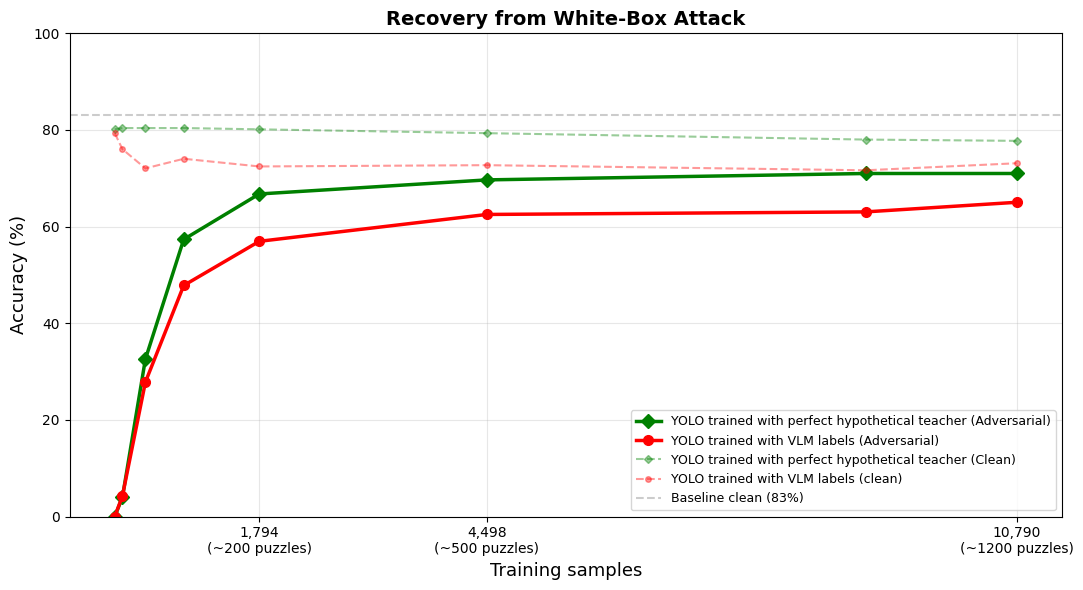

In [15]:
# ── Plot: Sample efficiency (consistent style with grey-box escalation plot) ──────
fig, ax = plt.subplots(figsize=(11, 6))

# Show only key puzzle counts for cleaner plot
SHOW_PUZZLES = [10, 20, 50, 100, 200, 500, 1000, 1200]
ns_show = [n for n in sorted(vlm_results.keys()) if n in SHOW_PUZZLES]
xs_show = [sample_counts[n] for n in ns_show]

# Adversarial accuracy (main story)
ax.plot(xs_show, [gt_results[n]['adv']*100 for n in ns_show], 'g-D',
        label='YOLO trained with perfect hypothetical teacher (Adversarial)', linewidth=2.5, markersize=7)
ax.plot(xs_show, [vlm_results[n]['adv']*100 for n in ns_show], 'r-o',
        label='YOLO trained with VLM labels (Adversarial)', linewidth=2.5, markersize=7)

# Clean accuracy
ax.plot(xs_show, [gt_results[n]['clean']*100 for n in ns_show], 'g--D',
        label='YOLO trained with perfect hypothetical teacher (Clean)', linewidth=1.5, markersize=4, alpha=0.4)
ax.plot(xs_show, [vlm_results[n]['clean']*100 for n in ns_show], 'r--o',
        label='YOLO trained with VLM labels (clean)', linewidth=1.5, markersize=4, alpha=0.4)

ax.axhline(y=base_clean*100, color='gray', linestyle='--', alpha=0.4,
           label=f'Baseline clean ({base_clean:.0%})')

# Custom x-axis: show ~2000, ~5000, ~10000 with puzzle count beneath
key_ns = [200, 500, 1200]
key_ticks = [sample_counts[n] for n in key_ns]
key_labels = [f'{sample_counts[n]:,}\n(~{n} puzzles)' for n in key_ns]
ax.set_xticks(key_ticks)
ax.set_xticklabels(key_labels, fontsize=10)

ax.set_xlabel('Training samples', fontsize=13)
ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title('Recovery from White-Box Attack',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('sample_efficiency_pgd_balanced_v2_final.png', bbox_inches='tight', dpi=300)
plt.show()

In [14]:
# ── Per-class breakdown ─────────────────────────────────────────────────────────
N_SHOW = 1200
if N_SHOW in vlm_results:
    print(f'Per-class at N={N_SHOW} (balanced, transfer defense vs baseline attacks):')
    print(f'  {"Class":<14s} {"Train":>5s} {"Val":>4s} | {"VLM cln":>8s} {"VLM adv":>8s} | {"GT cln":>7s} {"GT adv":>7s}')
    print(f'  {"-"*60}')
    vpc = vlm_results[N_SHOW]['pc']
    gpc = gt_results[N_SHOW]['pc']
    for cn in sorted(set(list(vpc.keys())+list(gpc.keys()))):
        v = vpc.get(cn, {'cc':0,'ct':1,'ac':0,'at':1})
        g = gpc.get(cn, {'cc':0,'ct':1,'ac':0,'at':1})
        if v['ct']==0: continue
        n_train = len(class_groups.get(cn, []))
        print(f'  {cn:<14s} {n_train:>5d} {v["ct"]:>4d} | {v["cc"]/v["ct"]:>7.0%} {v["ac"]/v["at"]:>7.0%} | {g["cc"]/max(g["ct"],1):>6.0%} {g["ac"]/max(g["at"],1):>6.0%}')

print(f'\n✓ Step 3a v2 complete.')

Per-class at N=1200 (balanced, transfer defense vs baseline attacks):
  Class          Train  Val |  VLM cln  VLM adv |  GT cln  GT adv
  ------------------------------------------------------------
  Bicycle          725   74 |     93%     85% |    95%    84%
  Bridge           476   74 |     89%     84% |    80%    72%
  Bus             1141   74 |     91%     84% |    92%    85%
  Car             3455   72 |     68%     62% |    71%    62%
  Chimney           39   17 |     88%     76% |    41%    29%
  Crosswalk       1182   74 |     74%     69% |    93%    86%
  Hydrant          898   74 |    100%     97% |   100%   100%
  Motorcycle        27   74 |     51%     28% |    28%    22%
  Mountain          11    2 |      0%      0% |     0%     0%
  Other           1363   72 |      3%      0% |    64%    56%
  Palm             856   74 |     68%     57% |    81%    76%
  Traffic Light    737   74 |     91%     81% |    84%    78%

✓ Step 3a v2 complete.
